# Rapid Sentiment Triage for Open-Ended Survey Responses

**The problem this solves:** a survey closes the day before a leadership briefing and there are 1,000+ open-ended comments. Nobody has time to read them all, but leadership needs to know how respondents are feeling, and the most critical comments need human eyes first.

**The approach:** score every open-ended response with VADER sentiment analysis within minutes of survey close, then split responses into a "flagged for review" queue (any negative sentiment detected) and an "other responses" queue. The output is a review-ready Excel workbook with columns for a human analyst to confirm, categorize, and note each flagged response.

This is a deliberately human-in-the-loop design. The model does the sorting; a person does the judging.

> **Note on data:** all data in this notebook is synthetic, generated to demonstrate the workflow. It is modelled on the *shape* of a real provider survey I analyzed professionally, but contains no real respondents, organizations, or results.

## 1. Setup and load

The survey export is in wide format: one row per respondent, with each open-ended question in its own column.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon', quiet=True)

df = pd.read_csv('data/synthetic_survey_responses.csv')

# Open-ended question columns and plain-language labels
open_questions = {
    'OPEN_INFLUENCE': 'What influenced your decision to join?',
    'OPEN_CHALLENGES': 'What are the biggest challenges?',
    'OPEN_PROGRAMS': 'Which programs matter most and why?',
    'OPEN_RECOMMEND': 'Would you recommend joining? Why or why not?',
    'OPEN_ADDITIONAL': 'Any additional comments?',
}

print(f"Respondents: {len(df)}")
df[['respondent_id'] + list(open_questions)].head()

Respondents: 412


,respondent_id,OPEN_INFLUENCE,OPEN_CHALLENGES,OPEN_PROGRAMS,OPEN_RECOMMEND,OPEN_ADDITIONAL
0,R1000,NaN,NaN,NaN,NaN,NaN
1,R1001,NaN,NaN,It depends on the needs of each community.,NaN,NaN
2,R1002,No additional comments at this time.,Too much administrative burden and not enough ...,NaN,Strong local leadership and good communication...,Funding feels unstable and we are worried abou...
3,R1003,Strong local leadership and good communication...,The reporting requirements are a waste of clin...,I am frustrated that decisions are made withou...,NaN,There is a serious lack of transparency around...
4,R1004,No additional comments at this time.,There is a serious lack of transparency around...,NaN,NaN,Our practice facilitator has been outstanding ...


## 2. Reshape from wide to long

Sentiment scoring works on one response at a time, so I melt the wide export into a long table: one row per (respondent, question, response). Empty responses are dropped here, which is also where we learn how many people actually used the open-ended fields.

In [2]:
id_cols = ['respondent_id', 'MEMBER', 'NETWORK_ID']

long_df = (
    df[id_cols + list(open_questions)]
    .melt(id_vars=id_cols, var_name='question_code', value_name='response')
)
long_df['question'] = long_df['question_code'].map(open_questions)

# Keep only rows with an actual response
long_df = long_df[long_df['response'].notna() & (long_df['response'].str.strip() != '')].copy()

print(f"Open-ended responses to score: {len(long_df)}")
print(f"Unique respondents who left at least one comment: {long_df['respondent_id'].nunique()}")

Open-ended responses to score: 961
Unique respondents who left at least one comment: 390


## 3. Score sentiment with VADER

**Why VADER:** it is fast, requires no training data, and is built for short informal text. For a same-day triage task those properties matter more than squeezing out a few points of accuracy with a heavier model.

**Known limitations I design around:** VADER misreads sarcasm, domain-specific phrasing, and comments that are negative in substance but neutral in tone ("funding was reduced" carries no negative words). That is exactly why the output of this step is a *review queue*, not a conclusion. The threshold is intentionally sensitive: any non-zero negative score gets flagged, trading false positives for very few false negatives.

In [3]:
sia = SentimentIntensityAnalyzer()

def score(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)
    return {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}

scores = long_df['response'].apply(score).apply(pd.Series)
scored = pd.concat([long_df.reset_index(drop=True), scores.reset_index(drop=True)], axis=1)

scored[['respondent_id', 'question', 'response', 'neg', 'compound']].head(8)

,respondent_id,question,response,neg,compound
0,R1002,What influenced your decision to join?,No additional comments at this time.,0.306,-0.2960
1,R1003,What influenced your decision to join?,Strong local leadership and good communication...,0.000,0.8271
2,R1004,What influenced your decision to join?,No additional comments at this time.,0.306,-0.2960
3,R1006,What influenced your decision to join?,The after hours program works well and reduces...,0.154,-0.0258
4,R1009,What influenced your decision to join?,More information sessions would be useful.,0.000,0.4404
5,R1013,What influenced your decision to join?,Access to allied health staff has been excelle...,0.000,0.7717
6,R1014,What influenced your decision to join?,Communication from the program has been poor a...,0.417,-0.6124
7,R1019,What influenced your decision to join?,I am frustrated that decisions are made withou...,0.254,-0.5267


## 4. Triage: split into review queues

Responses with any detected negative sentiment go to a dedicated sheet, sorted so the strongest negatives surface first. Empty columns are added for the human reviewer: confirming the flag, tagging the theme, marking whether it is in scope for the current project, and free-text notes. The structure of the workbook *is* the review process.

In [4]:
flagged = scored[scored['neg'] > 0].sort_values('compound').copy()
other = scored[scored['neg'] == 0].copy()

review_columns = ['Flag Confirmed', 'Theme', 'In Scope', 'Reviewer Notes']
for frame in (flagged, other):
    for col in review_columns:
        frame[col] = ''

print(f"Flagged for review: {len(flagged)} responses ({len(flagged)/len(scored):.0%} of all responses)")
print(f"Other responses:    {len(other)}")

Flagged for review: 511 responses (53% of all responses)
Other responses:    450


## 5. Topline numbers for the briefing

These are the figures leadership actually asks for: how many people commented, and what share of them expressed any negative sentiment.

In [5]:
total_responses = len(scored)
unique_participants = scored['respondent_id'].nunique()
flagged_participants = flagged['respondent_id'].nunique()

print(f"Total open-ended responses:                  {total_responses}")
print(f"Responses with negative sentiment detected:  {len(flagged)} ({len(flagged)/total_responses:.1%})")
print(f"Participants who left comments:              {unique_participants}")
print(f"Participants with 1+ negative response:      {flagged_participants} ({flagged_participants/unique_participants:.1%})")

Total open-ended responses:                  961
Responses with negative sentiment detected:  511 (53.2%)
Participants who left comments:              390
Participants with 1+ negative response:      320 (82.1%)


## 6. Where is the negativity concentrated?

Knowing *which questions* attract negative sentiment tells you where the substantive concerns live, and which sections of the review queue to read first.

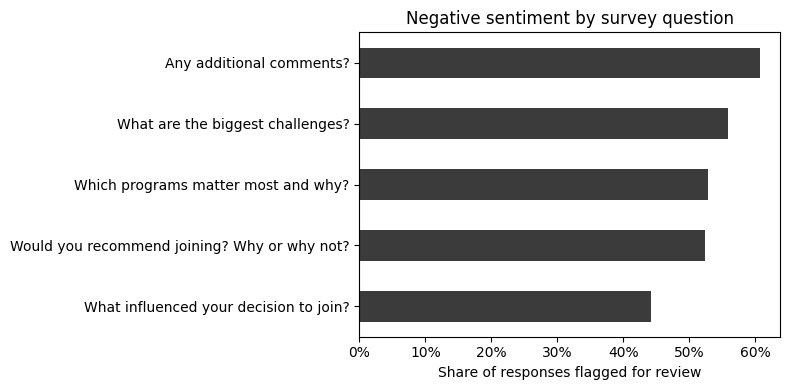

In [6]:
by_question = (
    scored.assign(is_flagged=scored['neg'] > 0)
    .groupby('question')['is_flagged']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
by_question.plot.barh(color='#3B3B3B', ax=ax)
ax.set_xlabel('Share of responses flagged for review')
ax.set_ylabel('')
ax.set_title('Negative sentiment by survey question')
ax.xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()

## 7. Export the review workbook

One file, three sheets: everything, the flagged queue, and the remainder. Timestamped so reruns never overwrite a reviewed copy.

In [7]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
file_name = f'sentiment_triage_{timestamp}.xlsx'

export_cols = (id_cols + ['question', 'response', 'neg', 'neu', 'pos', 'compound'] + review_columns)

with pd.ExcelWriter(file_name) as writer:
    scored.reindex(columns=export_cols).to_excel(writer, sheet_name='All Responses', index=False)
    flagged.reindex(columns=export_cols).to_excel(writer, sheet_name='Flagged for Review', index=False)
    other.reindex(columns=export_cols).to_excel(writer, sheet_name='Other Responses', index=False)

print(f"Review workbook exported: {file_name}")

Review workbook exported: sentiment_triage_20260611_2228.xlsx


## What this looked like in practice

When I ran this workflow on a real 150-response provider survey, the full pipeline (survey close to review-ready workbook) took under an hour. The triage meant analysts read the highest-risk comments first, and leadership had a defensible same-day read on sentiment ahead of potential public statements by a stakeholder association.

**If I extended this:** compare VADER flags against a transformer-based classifier on a labelled sample to quantify the false-negative rate, and add simple keyword tagging to pre-suggest themes for the reviewer.